In [1]:
import xarray as xr
import matplotlib.pyplot as plt

In [2]:
!ls ../../../inputs/raw_data/

inputs_levante.sh  mhw_monthly.nc	     zos_mld_to.nc
mask		   variables_exploration.py


In [3]:
!ls ../../../inputs/processed_data/

alinging_times.py	     target_preprocessing.py
north_sea_extreme_mhw_30.nc  training_dataset1.nc


In [4]:
zos = xr.open_dataset("../../../inputs/raw_data/zos_mld_to.nc")

In [5]:
t_ds = xr.open_dataset("../../../inputs/processed_data/training_dataset1.nc")

In [17]:
t_ds 

<xarray.Dataset> Size: 162MB
Dimensions:    (time: 480, lon: 201, lat: 140)
Coordinates:
  * time       (time) datetime64[ns] 4kB 1985-01-16 ... 2024-12-16
  * lon        (lon) float64 2kB -80.0 -79.5 -79.0 -78.5 ... 18.5 19.0 19.5 20.0
  * lat        (lat) float64 1kB 0.25 0.75 1.25 1.75 ... 68.25 68.75 69.25 69.75
Data variables:
    to         (time, lat, lon) float32 54MB ...
    zos        (time, lat, lon) float32 54MB ...
    mld        (time, lat, lon) float32 54MB ...
    land_mask  (lat, lon) float64 225kB ...
    target     (time) int64 4kB ...
Attributes: (12/18)
    CDI:                 Climate Data Interface version 2.5.0 (https://mpimet...
    Conventions:         CF-1.6
    source:              @
    institution:         Max Planck Institute for Meteorology/Deutscher Wette...
    title:               ICON simulation
    history:             Mon Feb 02 19:57:15 2026: cdo delete,month=2,day=29 ...
    ...                  ...
    contact:             cristina.radin@uni-hamburg.de
    time_coverage:       from 1940-01-01T00:00:00 to 2024-12-01T00:00:00
    spatial_resolution:  0.5 degree regridded from ICON
    variables_included:  to (sea water potential temperature at depth 8 m), z...
    region:              North Atlantic (-80 to 20 E, 0 to 70 N)
    note:                Leap days (Feb 29) removed for temporal consistency

zos_mld_to.nc raw data:

time (1020 months) x lon (201) xlat (140)

spatial resolution 0.5 degree

North Atlantic only

- tos: sea water potential temperature (here depth 8m)
- zos: surface elevation
- mld: mixed layer depth [m]

# Inputs


In [11]:
zos

<xarray.Dataset> Size: 344MB
Dimensions:  (time: 1020, lon: 201, lat: 140, depth: 1)
Coordinates:
  * time     (time) datetime64[ns] 8kB 1940-01-01 1940-02-01 ... 2024-12-01
  * lon      (lon) float64 2kB -80.0 -79.5 -79.0 -78.5 ... 18.5 19.0 19.5 20.0
  * lat      (lat) float64 1kB 0.25 0.75 1.25 1.75 ... 68.25 68.75 69.25 69.75
  * depth    (depth) float64 8B 8.0
Data variables:
    to       (time, depth, lat, lon) float32 115MB ...
    zos      (time, lat, lon) float32 115MB ...
    mld      (time, lat, lon) float32 115MB ...
Attributes: (12/18)
    CDI:                 Climate Data Interface version 2.5.0 (https://mpimet...
    Conventions:         CF-1.6
    source:              @
    institution:         Max Planck Institute for Meteorology/Deutscher Wette...
    title:               ICON simulation
    history:             Mon Feb 02 19:57:15 2026: cdo delete,month=2,day=29 ...
    ...                  ...
    contact:             cristina.radin@uni-hamburg.de
    time_coverage:       from 1940-01-01T00:00:00 to 2024-12-01T00:00:00
    spatial_resolution:  0.5 degree regridded from ICON
    variables_included:  to (sea water potential temperature at depth 8 m), z...
    region:              North Atlantic (-80 to 20 E, 0 to 70 N)
    note:                Leap days (Feb 29) removed for temporal consistency

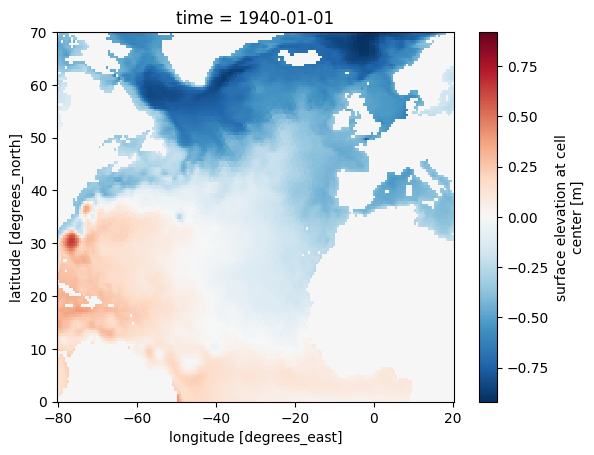

In [24]:
%matplotlib inline
zos.zos.isel(time=0).plot(x="lon",y="lat")
plt.show()

# Targets
time (months) x lon (1000) x lat (700)

spatial resolution 0.1

variables:
- days with heatwave



In [6]:
mhw = xr.open_dataset("../../../inputs/raw_data/mhw_monthly.nc")

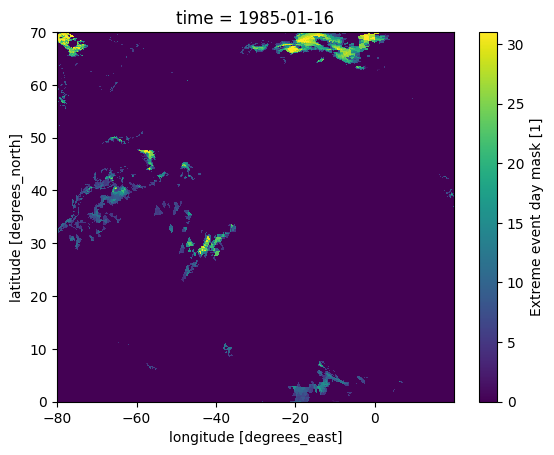

<xarray.Dataset> Size: 162MB
Dimensions:    (time: 480, lon: 201, lat: 140)
Coordinates:
  * time       (time) datetime64[ns] 4kB 1985-01-16 ... 2024-12-16
  * lon        (lon) float64 2kB -80.0 -79.5 -79.0 -78.5 ... 18.5 19.0 19.5 20.0
  * lat        (lat) float64 1kB 0.25 0.75 1.25 1.75 ... 68.25 68.75 69.25 69.75
Data variables:
    to         (time, lat, lon) float32 54MB ...
    zos        (time, lat, lon) float32 54MB ...
    mld        (time, lat, lon) float32 54MB ...
    land_mask  (lat, lon) float64 225kB ...
    target     (time) int64 4kB ...
Attributes: (12/18)
    CDI:                 Climate Data Interface version 2.5.0 (https://mpimet...
    Conventions:         CF-1.6
    source:              @
    institution:         Max Planck Institute for Meteorology/Deutscher Wette...
    title:               ICON simulation
    history:             Mon Feb 02 19:57:15 2026: cdo delete,month=2,day=29 ...
    ...                  ...
    contact:             cristina.radin@uni-hamburg.de
    time_coverage:       from 1940-01-01T00:00:00 to 2024-12-01T00:00:00
    spatial_resolution:  0.5 degree regridded from ICON
    variables_included:  to (sea water potential temperature at depth 8 m), z...
    region:              North Atlantic (-80 to 20 E, 0 to 70 N)
    note:                Leap days (Feb 29) removed for temporal consistency

In [8]:
%matplotlib inline
mhw.days_total.isel(time=0).plot(x="lon", y="lat")
plt.show()

t_ds

In [10]:
t_ds.target.values

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1,
       0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0,

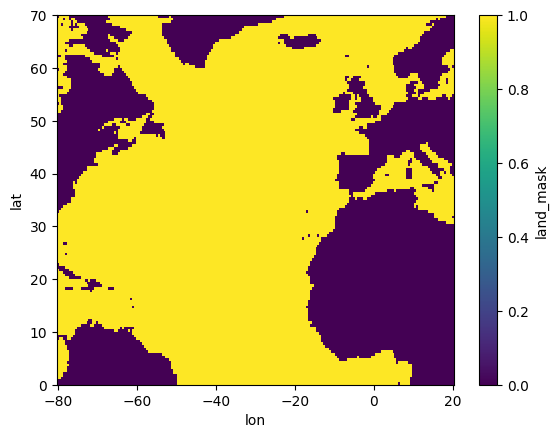

In [11]:
%matplotlib inline
t_ds.land_mask.plot()
plt.show()

In [12]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np

vars_to_use = ["to", "zos", "mld"]

pca_ds = t_ds[vars_to_use]
feature_dims = [d for d in pca_ds.dims if d != "time"]

print("Feature dimensions:", feature_dims)

X = (
    pca_ds.to_array("variable")
    .stack(feature=("variable", *feature_dims))
    .transpose("time", "feature")
)

# Drop any spatial points with NaNs across time before PCA.
X = X.dropna("feature", how="any")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X.values)

pca = PCA(n_components=10)
scores = pca.fit_transform(X_scaled)

pc = xr.DataArray(
    scores,
    dims=("time", "pc"),
    coords={"time": X["time"], "pc": np.arange(1, pca.n_components_ + 1)},
    name="pc_scores",
)

loadings = xr.DataArray(
    pca.components_,
    dims=("pc", "feature"),
    coords={"pc": pc["pc"], "feature": X["feature"]},
    name="pc_loadings",
)

print("Explained variance ratio:", pca.explained_variance_ratio_)



loadings_unstacked = loadings.unstack("feature")


Feature dimensions: ['lat', 'lon']
Explained variance ratio: [0.52482563 0.10541897 0.05041569 0.03262131 0.02425922 0.01785986
 0.01639734 0.01132313 0.00949887 0.0082916 ]


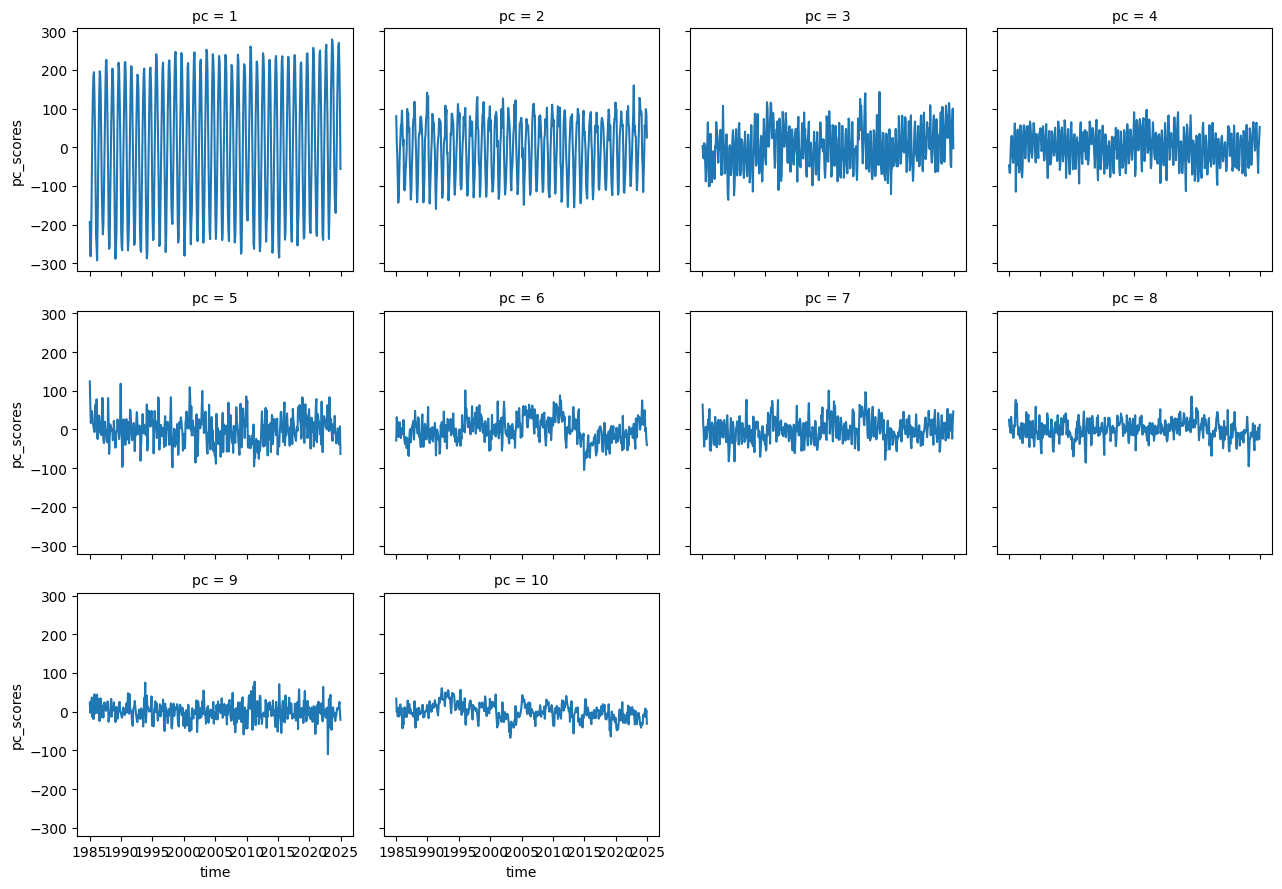

In [13]:
%matplotlib inline
pc.plot.line(x="time", col="pc", col_wrap=4)
plt.show()

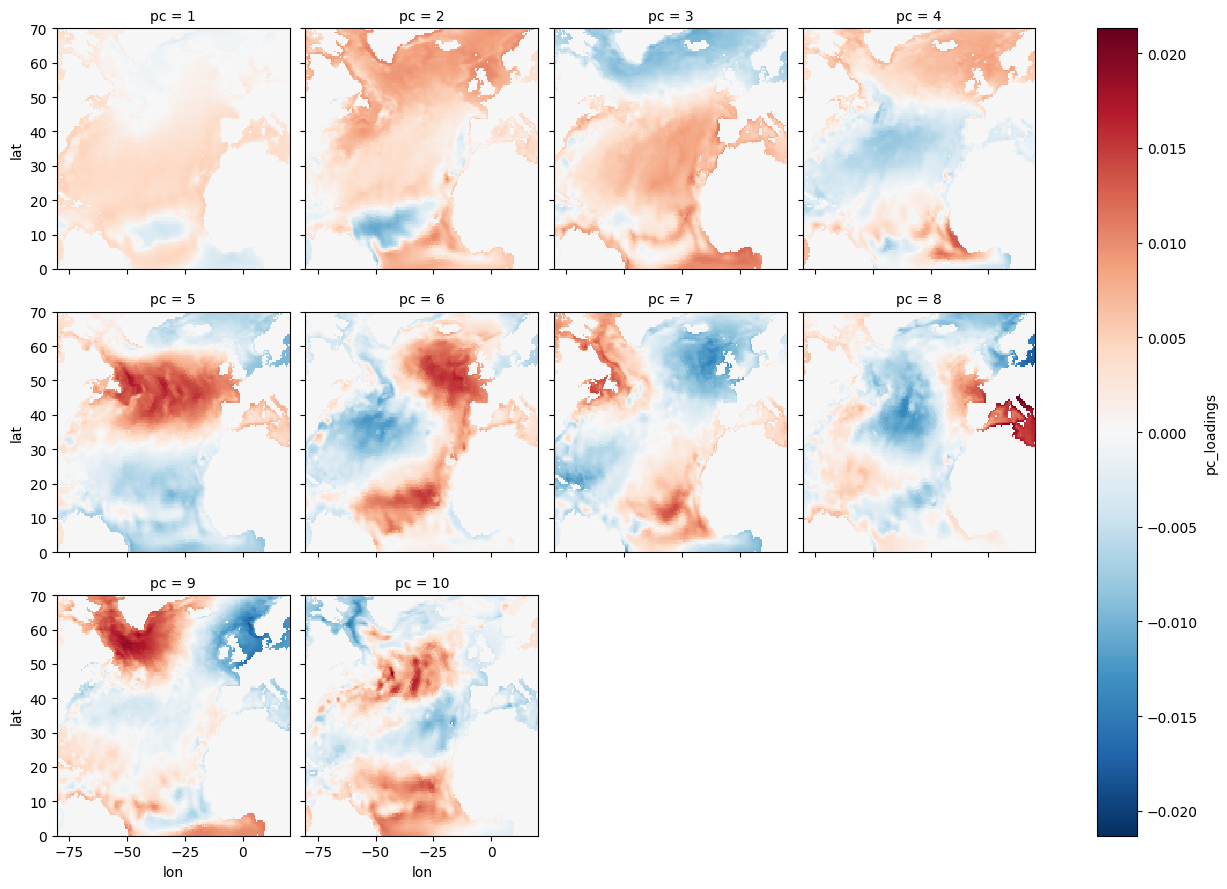

In [14]:
%matplotlib inline
loadings_unstacked.sel(variable="zos").plot(x="lon", y="lat", col="pc", col_wrap=4)
plt.show()

In [27]:
#!pip install --user xgboost

  Using cached xgboost-3.2.0-py3-none-manylinux_2_28_x86_64.whl.metadata (2.1 kB)
  Using cached nvidia_nccl_cu12-2.29.7-py3-none-manylinux_2_18_x86_64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-manylinux_2_28_x86_64.whl (131.7 MB)
Using cached nvidia_nccl_cu12-2.29.7-py3-none-manylinux_2_18_x86_64.whl (293.6 MB)

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [24]:
pc

<xarray.DataArray 'pc_scores' (time: 480, pc: 10)> Size: 19kB
array([[-192.95288  ,   80.39307  ,    3.316726 , ...,   24.99835  ,
          22.953676 ,   33.578495 ],
       [-279.10815  ,   17.06548  ,  -23.839249 , ...,    6.5258074,
          -2.8208103,   -1.0925148],
       [-281.6063   ,  -21.108606 ,  -28.784647 , ...,    7.5435934,
          26.246235 ,    7.38408  ],
       ...,
       [ 207.08972  ,   98.61202  ,   76.97591  , ...,    2.282251 ,
          25.041069 ,  -13.015378 ],
       [ 102.02864  ,   88.789024 ,  100.085915 , ...,  -24.740105 ,
          -1.3951609,    3.51289  ],
       [ -55.82208  ,   25.282648 ,   -2.3278186, ...,   12.056909 ,
         -21.010365 ,  -31.030859 ]], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 4kB 1985-01-16 ... 2024-12-16
  * pc       (pc) int64 80B 1 2 3 4 5 6 7 8 9 10

In [15]:
import xgboost as xgb
xgb_model = xgb.XGBClassifier()

param_space_edges = {
    'objective': ['binary:logistic'],
    'max_depth': [4, 8],
    'learning_rate': [0.05, 0.2],
    'subsample': [0.6, 0.9],
    'n_estimators' : [100, 1000],
    'lambda' : [0.05, 0.5],
    'gamma' : [0, 0.5],
}



ModuleNotFoundError: No module named 'xgboost'

In [ ]:
my_search = BayesSearchCV(
            xgb_model,
            param_space,
            n_jobs=-1,
            n_iter = 100
        )

In [ ]:
x_train = pc.isel(time=slice(0,400)).values
y_train = t_ds.target.values

In [ ]:
my_search.fit(x_train, y_train)

best_params = my_search.best_params_
best_model = xgboost.XGBClassifier(**best_params)
best_model.fit(x_train, y_train)

if model_name is not None:
    print(f"Saving best model trained on x_train to {model_name}.json")
    best_model.save_model(model_name)

print("Best set of hyperparameters: ", search_cv.best_params_)
print("Best score: ", search_cv.best_score_)